## Import libraries

In [31]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData
from alignment_methods import reprojection_consistency_score
import h5py
import numpy as np
from skimage.transform import pyramid_gaussian
from scipy.ndimage import zoom

def tomo_data(file,redo_align=False):
    try:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    except KeyError:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    angles = angles * np.pi / 180
    #Shift angles to be centered around 0
    angles = angles - np.mean(angles)
    return projs, angles


## Import real Data

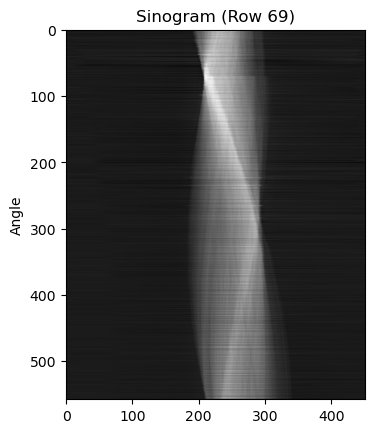

Loading downsampled cache: /home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2_ds4.hdf5
(556, 146, 452)
Number of angles: 556


In [32]:
import os
tomo.displayWorkingSinogram(row_index=tomo.workingProjections.shape[0] // downsample // 2)
downsample = 4
recon_alg = 'SIRT_CUDA'
# filename = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"
filename = "/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5"

cached_filename = filename.replace(".hdf5", f"_ds{downsample}.hdf5")

if os.path.exists(cached_filename):
    print(f"Loading downsampled cache: {cached_filename}")
    projections, angles = tomo_data(cached_filename)
    print(projections.shape)
    tomo = tomoData(projections, angles)
else:
# if True:
    print("Cache not found — loading full dataset...")
    projections_og, angles = tomo_data(filename, redo_align=True)
    print("Full dataset shape:", projections_og.shape)

    #Remove projection and angle 26
    projections_og = np.delete(projections_og, 26, axis=0)
    angles = np.delete(angles, 26)

    #Remove projection and angle 19
    projections_og = np.delete(projections_og, 19, axis=0)
    angles = np.delete(angles, 19)
    _needs_downsample = True

if not os.path.exists(cached_filename):
# if True:
    print("Downsampling...")
    projections = zoom(projections_og, (1, 1/downsample, 1/downsample), order=1)
    print(projections.shape)

    print(f"Saving downsampled cache to: {cached_filename}")
    with h5py.File(cached_filename, 'w') as hf:
        hf.create_dataset('data', data=projections)
        hf.create_dataset('angles', data=angles * 180 / np.pi)  # save back in degrees

    tomo = tomoData(projections, angles)

num_angles = projections.shape[0] if os.path.exists(cached_filename) else projections_og.shape[0]
print(f"Number of angles: {num_angles}")

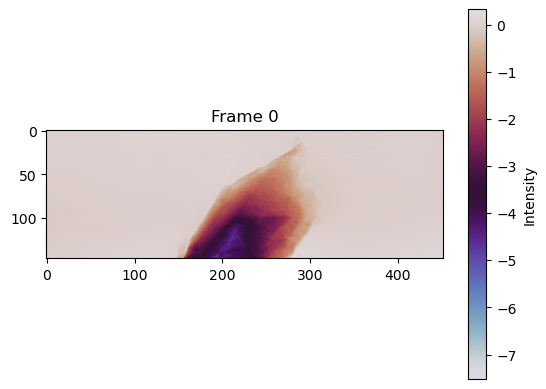

In [33]:
print(projections.shape)
tomo.makeNotebookProjMovie()

## Align Data

In [34]:
# # Show bad reconstruction prior to alignment
# tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
# tomo.normalize(isPhaseData=True)

# tomo.reconstruct(algorithm=recon_alg)
# print("\nBad reconstruction prior to alignment")
# badRecon = tomo.recon.copy()
# MoviePlotter(badRecon)

In [35]:
# # Reprojection Consistency Score — before alignment
# rcs_before, _, _ = tomo.reprojection_consistency_score(plot=False)

# #Sinogram consistency score — before alignment
# scs_before, _, _, _, _ = tomo.sinogram_consistency_score(plot=False)



Normalizing projections


Cross-Correlation Alignment  [4x downsample | ROI y=[0, 146] x=[0, 452] | gradient mode]


Iteration 1/5: 100%|██████████| 555/555 [00:04<00:00, 123.88it/s]


  Projection 278 shift: y=3.2000 px, x=-28.4800 px


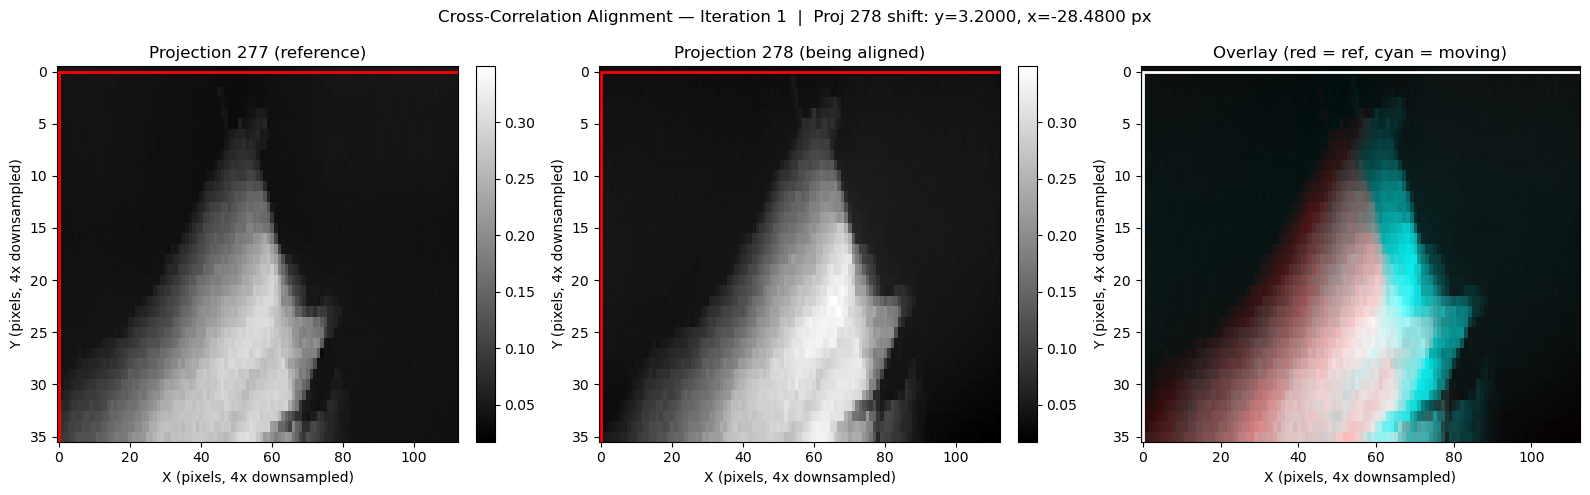

Iteration 1: avg shift = 16.6565 px, max shift = 82.9147 px


Iteration 2/5: 100%|██████████| 555/555 [00:04<00:00, 125.50it/s]


Iteration 2: avg shift = 3.6836 px, max shift = 19.5907 px


Iteration 3/5: 100%|██████████| 555/555 [00:04<00:00, 126.37it/s]


Iteration 3: avg shift = 0.8181 px, max shift = 16.2240 px


Iteration 4/5: 100%|██████████| 555/555 [00:04<00:00, 125.44it/s]


Iteration 4: avg shift = 0.3820 px, max shift = 7.5217 px


Iteration 5/5: 100%|██████████| 555/555 [00:04<00:00, 126.35it/s]


Iteration 5: avg shift = 0.2955 px, max shift = 11.6273 px
Maximum iterations reached without convergence.
Centering Projections
Original center: 226.0
Center of frame: 226
Projections are currently centered at pixel 226.0. Residual offset: 0.0


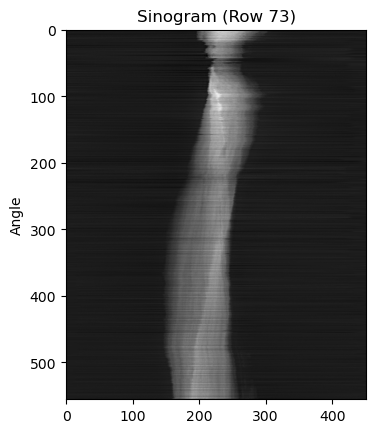

In [36]:
# tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

# XCA Pass 1 - coarse (downsample=4)
tomo.cross_correlate_align(
    tolerance=0, maxShiftTolerance=0, max_iterations=5, stepRatio=0.8,
    downsample=4, use_grad=True,
    yROI_Range=None, xROI_Range=None, isFull360=False, plot=True
)
tomo.center_projections()

tomo.displayWorkingSinogram()




Cross-Correlation Alignment  [2x downsample | ROI y=[0, 96] x=[62, 390] | gradient mode]


Iteration 1/10: 100%|██████████| 555/555 [00:15<00:00, 35.52it/s]


  Projection 278 shift: y=0.0000 px, x=0.0000 px


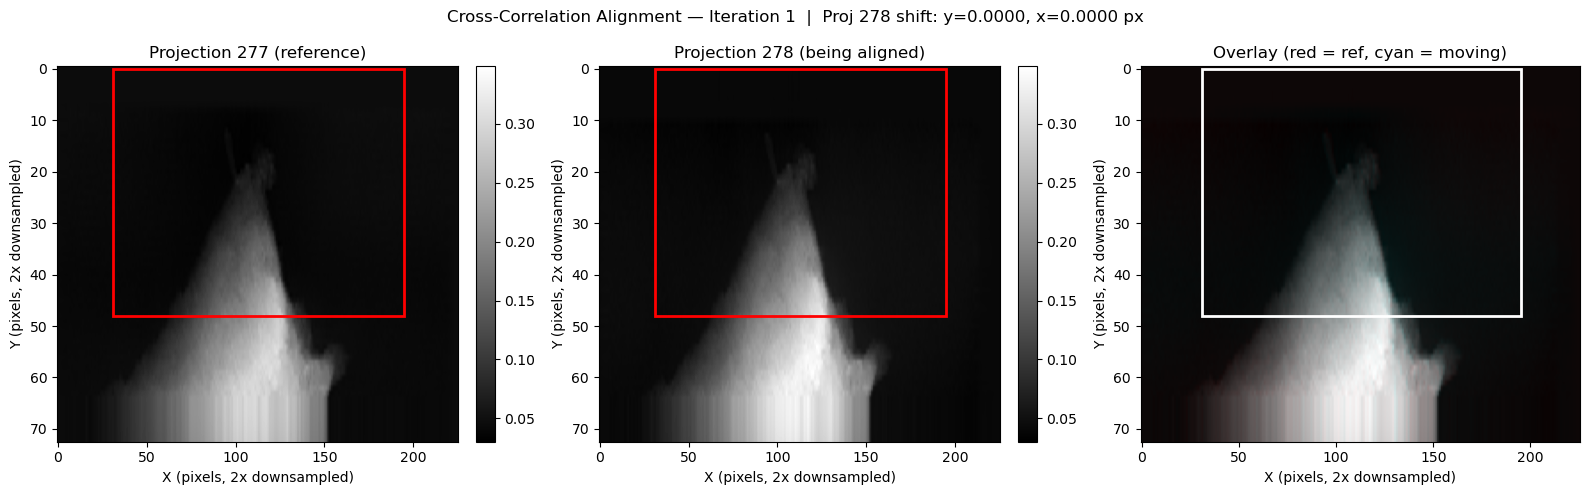

Iteration 1: avg shift = 0.7925 px, max shift = 15.6133 px


Iteration 2/10: 100%|██████████| 555/555 [00:10<00:00, 52.26it/s]


Iteration 2: avg shift = 0.2017 px, max shift = 4.2460 px


Iteration 3/10: 100%|██████████| 555/555 [00:10<00:00, 52.26it/s]


Iteration 3: avg shift = 0.1016 px, max shift = 2.2457 px


...

Iteration 8: avg shift = 0.0420 px, max shift = 0.6597 px


Iteration 9/10: 100%|██████████| 555/555 [00:10<00:00, 53.84it/s]


Iteration 9: avg shift = 0.0387 px, max shift = 0.5367 px


Iteration 10/10: 100%|██████████| 555/555 [00:10<00:00, 52.00it/s]


Iteration 10: avg shift = 0.0335 px, max shift = 1.3315 px
Maximum iterations reached without convergence.


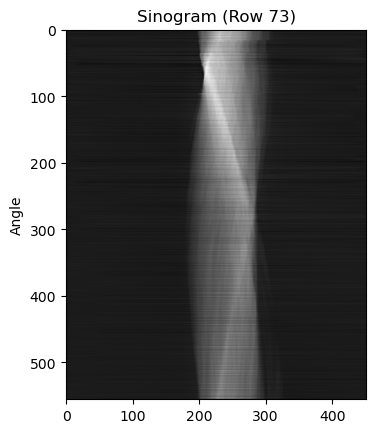

In [37]:

# XCA Pass 2 - medium
tomo.cross_correlate_align(
    tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.8,
    downsample=2, use_grad=True,
    yROI_Range=[0, tomo.workingProjections.shape[1] - (200//downsample)], xROI_Range=[250//downsample, tomo.workingProjections.shape[2] - (250 // downsample)], isFull360=False, plot=True
)
tomo.displayWorkingSinogram()




Cross-Correlation Alignment  [full resolution | ROI y=[0, 71] x=[62, 390] | gradient mode]


Iteration 1/10: 100%|██████████| 555/555 [00:10<00:00, 51.60it/s]


  Projection 278 shift: y=-0.0400 px, x=0.3600 px


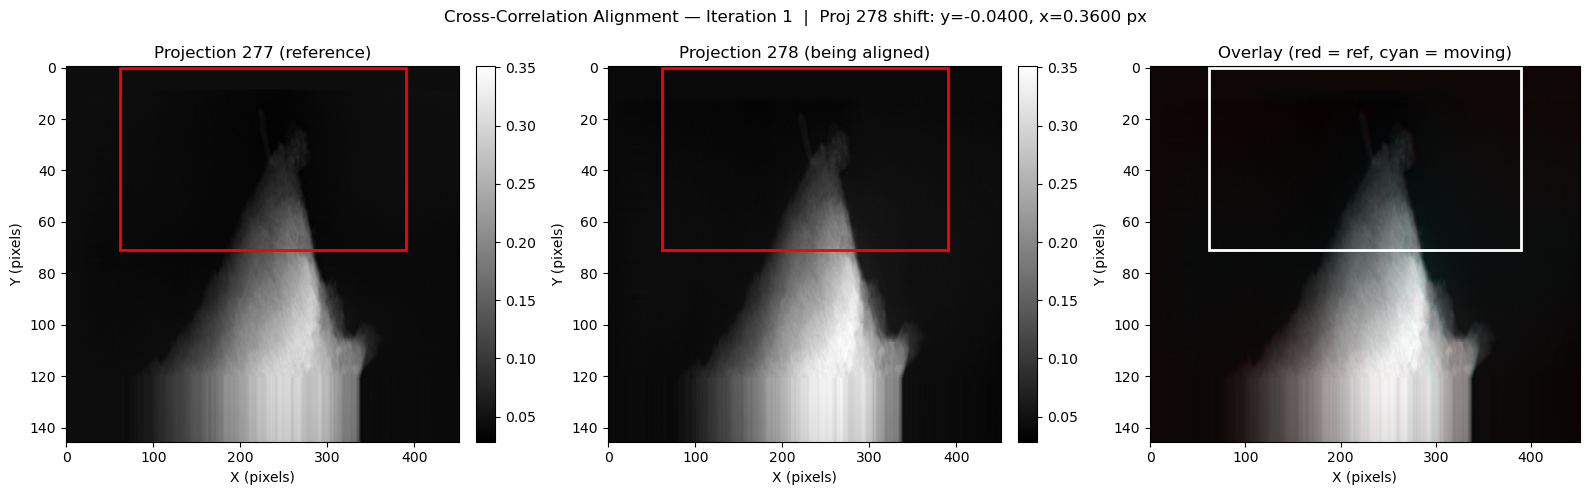

Iteration 1: avg shift = 0.3413 px, max shift = 5.7780 px


Iteration 2/10: 100%|██████████| 555/555 [00:10<00:00, 50.93it/s]


Iteration 2: avg shift = 0.0767 px, max shift = 0.9839 px


Iteration 3/10: 100%|██████████| 555/555 [00:10<00:00, 53.13it/s]


Iteration 3: avg shift = 0.0464 px, max shift = 2.0000 px


...

Iteration 8: avg shift = 0.0172 px, max shift = 0.1265 px


Iteration 9/10: 100%|██████████| 555/555 [00:10<00:00, 51.30it/s]


Iteration 9: avg shift = 0.0130 px, max shift = 0.2000 px


Iteration 10/10: 100%|██████████| 555/555 [00:10<00:00, 51.43it/s]


Iteration 10: avg shift = 0.0157 px, max shift = 0.2828 px
Maximum iterations reached without convergence.


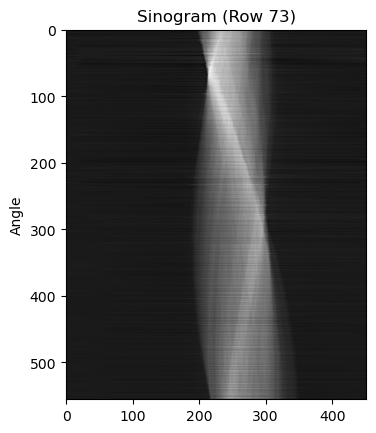

In [38]:

tomo.cross_correlate_align(
    tolerance=0, maxShiftTolerance=0, max_iterations=10, stepRatio=0.8,
    downsample=1, use_grad=True,
    yROI_Range=[0, tomo.workingProjections.shape[1] - (300//downsample)], xROI_Range=[250//downsample, tomo.workingProjections.shape[2] - (250 // downsample)], isFull360=False, plot=True
)
tomo.displayWorkingSinogram()


In [39]:
# tomo.make_updates_shift()
# tomo.data = tomo.finalProjections

# tomo.displayWorkingSinogram()

# tomo.reset_workingProjections()
# tomo.normalize(isPhaseData=True)
# tomo.displayWorkingSinogram()



Projection Matching Alignment (PMA) [optical_flow | gradient mode | matching_preprocess]
Centering Projections
Original center: 254.25
Center of frame: 226
Aligned projections shifted by -28.25 pixels
Projections are currently centered at pixel 226.0. Residual offset: 0.0

--- PMA Level 0 (1x downsampled, 10 iterations) ---
Using ROI: x=[87, 365], y=[0, 71] (downsampled by 1x)
H and W values are 146 and 452
Downsample ROI bounds are x=87 to 365, y=0 to 71


PMA Level 0 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

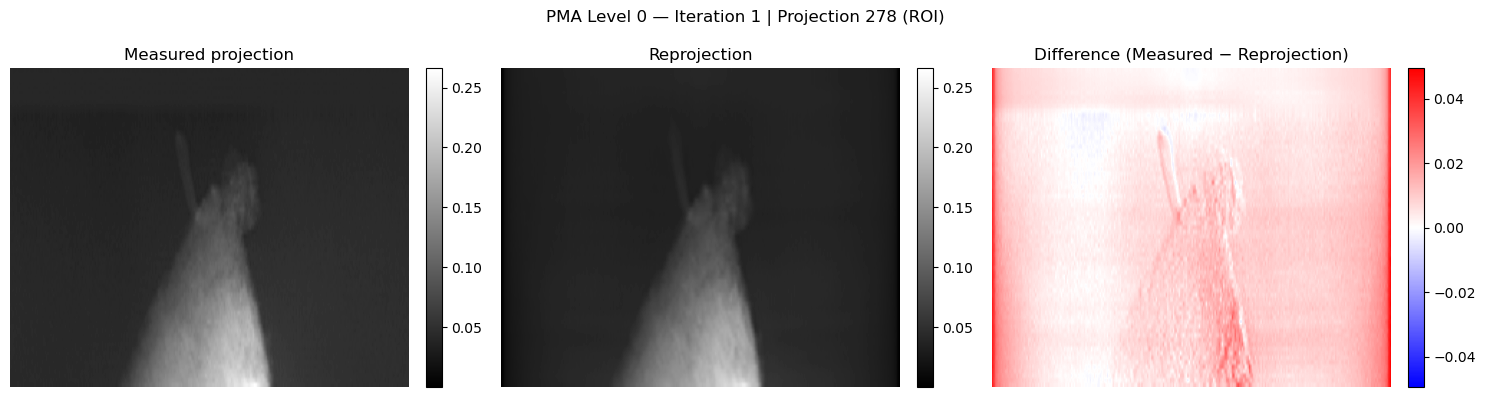

PMA Level 0 iterations:  10%|█         | 1/10 [01:11<10:41, 71.25s/it]

Iteration 1: avg shift = 0.0136 px, max shift = 0.0973 px


PMA Level 0 iterations:  20%|██        | 2/10 [01:42<06:20, 47.53s/it]

Iteration 2: avg shift = 0.0133 px, max shift = 0.0888 px


In [ ]:
# PMA - 3 levels, scale=2, of_sigma=2.0, stepRatio=0.8
recon_alg = 'SIRT_CUDA'
#set xROI range to be width of the total number of angles divided by downsample
maxWidth = tomo.num_angles // downsample
xROI_Range = [tomo.workingProjections.shape[2] // 2 - maxWidth, tomo.workingProjections.shape[2] // 2 + maxWidth]
tomo.PMA(
    levels=1, scale=1, iterations_per_level=[10],
    tolerance=0.00, algorithm=recon_alg, standardize=False, use_grad=True,
    shift_method='optical_flow', of_sigma=2.0, stepRatio=0.8, plot=True, xROI_Range=xROI_Range, yROI_Range=[0, tomo.workingProjections.shape[1] - (300//downsample)]
)

# tomo.makeNotebookProjMovie(show_trust_region=True)
tomo.displayWorkingSinogram()

In [ ]:
# Save the full accumulated shifts from all 4x alignment stages
shifts_4x = tomo.tracked_shifts.copy()
os.makedirs("alignedProjections", exist_ok=True)
np.save("alignedProjections/shifts_4x.npy", shifts_4x)
print(f"Saved 4x shifts: shape {shifts_4x.shape}, "
      f"max |y|={np.abs(shifts_4x[:,0]).max():.2f} px, "
      f"max |x|={np.abs(shifts_4x[:,1]).max():.2f} px")

# Single commit
tomo.make_updates_shift()

tomo.makeNotebookProjMovie()
tomo.reconstruct(algorithm=recon_alg)
print("\n4x downsampled reconstruction after full alignment")
tomo.makeNotebookReconMovie()

In [ ]:
tomo.displayReconOrthogonalSlices()

In [ ]:
# # Reprojection Consistency Score — after alignment
# rcs_after, _, _ = tomo.reprojection_consistency_score(plot=True)

# # Sinogram consistency score — after alignment
# scs_after, _, _, _, _ = tomo.sinogram_consistency_score(plot=True)

# # Fourier shell correlation resolution - after alignment
# res_after = tomo.fourier_shell_correlation(algorithm=recon_alg, plot=True)

In [ ]:
tomo.displayWorkingSinogram()

import matplotlib.pyplot as plt
row_index = tomo.workingProjections.shape[1] // 2
plt.imshow(tomo.finalProjections[:,row_index,:], cmap='gray')
plt.title(f'Sinogram (Row {row_index})')
plt.ylabel('Angle')
plt.show()

In [23]:
import tifffile
tifffile.imwrite("bestNotebookReconstruction(4xds).tiff", tomo.recon.astype("float32"))
tifffile.imwrite("bestNotebookAlignedProjections(4xds).tiff", tomo.finalProjections.astype("float32"))

## Stage 2: 2x Downsampled — Apply 4x Shifts × 2 + Fine-Tune PMA

In [ ]:
downsample_2x = 2
cached_filename_2x = filename.replace(".hdf5", f"_ds{downsample_2x}.hdf5")
print(f"Loading 2x cache: {cached_filename_2x}")
projections_2x, angles_2x = tomo_data(cached_filename_2x)
print(f"Shape: {projections_2x.shape}")
tomo2x = tomoData(projections_2x, angles_2x)

In [ ]:
tomo2x.reset_workingProjections()
tomo2x.normalize(isPhaseData=True)

shifts_2x = np.load("alignedProjections/shifts_4x.npy") * 2

# Apply to finalProjections via standard path
tomo2x.tracked_shifts = shifts_2x.copy()
tomo2x.make_updates_shift()

# Sync workingProjections so PMA reconstructs from the correctly-shifted data
tomo2x.workingProjections = np.copy(tomo2x.finalProjections)

tomo2x.makeNotebookProjMovie(show_trust_region=True)
tomo2x.displayWorkingSinogram(row_index=tomo2x.workingProjections.shape[0] // downsample_2x // 2)

In [ ]:
maxWidth_2x = tomo2x.num_angles // downsample_2x
xROI_Range_2x = [
    tomo2x.workingProjections.shape[2] // 2 - maxWidth_2x,
    tomo2x.workingProjections.shape[2] // 2 + maxWidth_2x
]
tomo2x.PMA(
    levels=1, scale=1, iterations_per_level=[5],
    tolerance=0.00, algorithm=recon_alg, standardize=False,
    shift_method='optical_flow', of_sigma=2.0, stepRatio=0.8, plot=True,
    xROI_Range=xROI_Range_2x,
    yROI_Range=[0, tomo2x.workingProjections.shape[1] - (300 // downsample_2x)]
)

tomo2x.make_updates_shift()
# tomo2x.makeNotebookProjMovie(show_trust_region=True)
tomo2x.displayWorkingSinogram(row_index=tomo2x.workingProjections.shape[0] // downsample_2x // 2)

In [ ]:
tomo2x.makeNotebookProjMovie()
tomo2x.reconstruct(algorithm=recon_alg)
print("\nFinal 2x staged-alignment reconstruction")
tomo2x.makeNotebookReconMovie()
tomo2x.displayReconOrthogonalSlices()

In [19]:
import tifffile
tifffile.imwrite("bestNotebookReconstruction(2xds_staged).tiff", tomo2x.recon.astype("float32"))
tifffile.imwrite("bestNotebookAlignedProjections(2xds_staged).tiff", tomo2x.finalProjections.astype("float32"))